In [1]:
import pandas as pd
df = pd.read_csv('cleaned_diabetic_data.csv')
df.shape

(69990, 53)

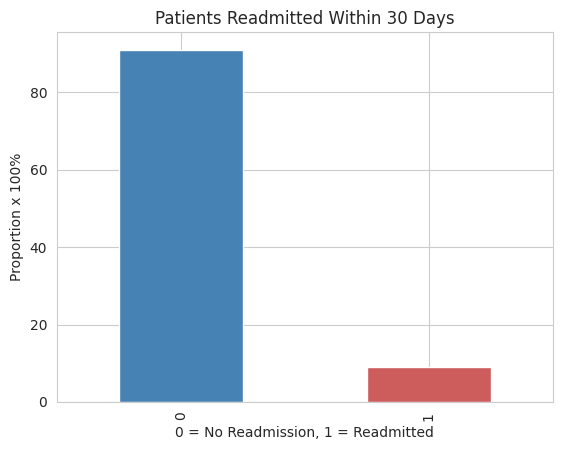

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# readmission within 30 days distribution
(df['readmitted_30'].value_counts(normalize=True) * 100).plot(
    kind='bar', color=['steelblue', 'indianred'])
plt.title('Patients Readmitted Within 30 Days')
plt.xlabel('0 = No Readmission, 1 = Readmitted')
plt.ylabel('Proportion x 100%')
plt.show()

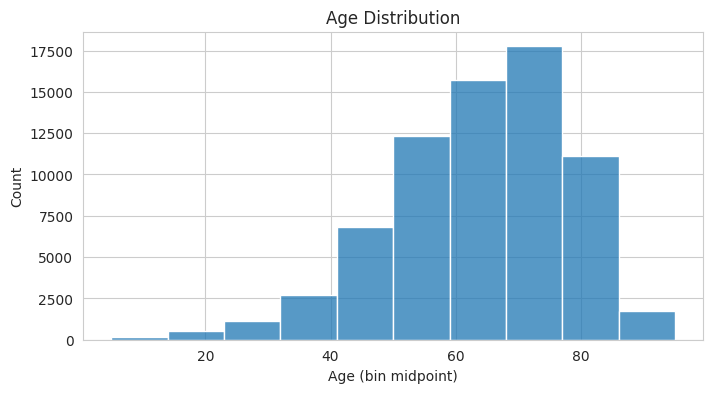

In [10]:
# age distribution
plt.figure(figsize=(8,4))
sns.histplot(df['age_midpoint'], bins=10, kde=False)
plt.title('Age Distribution')
plt.xlabel('Age (bin midpoint)')
plt.show()

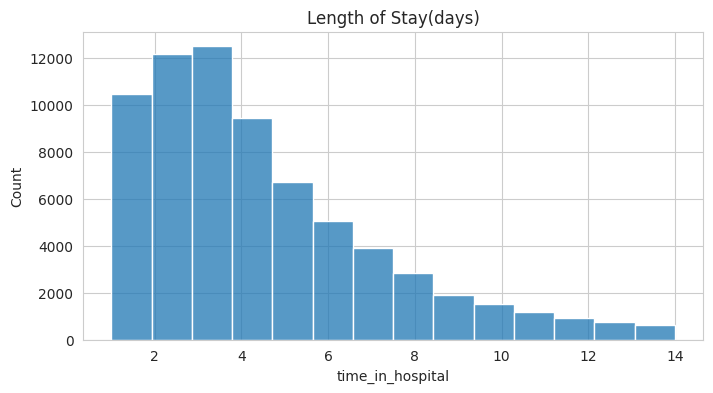

In [11]:
# time in hospital distribution
plt.figure(figsize=(8,4))
sns.histplot(df['time_in_hospital'], bins=14, kde=False)
plt.title('Length of Stay(days)')
plt.show()

age
[0-10)      0.019608
[10-20)     0.048689
[20-30)     0.074041
[30-40)     0.069837
[40-50)     0.074107
[50-60)     0.071249
[60-70)     0.090191
[70-80)     0.102360
[80-90)     0.107921
[90-100)    0.095400
Name: readmitted_30, dtype: float64


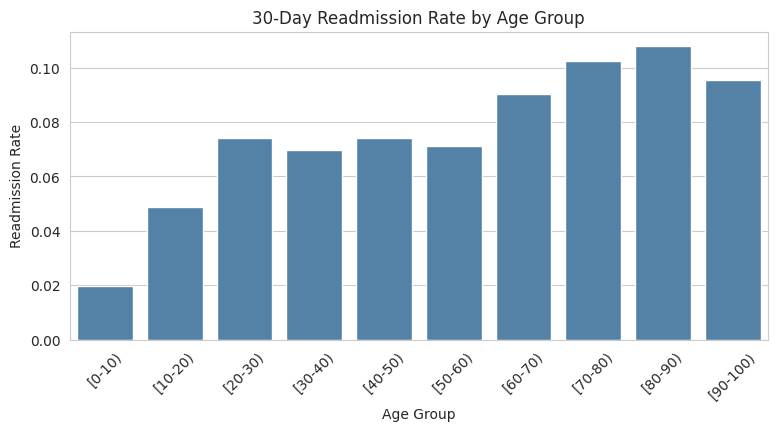

In [12]:
# readmission rate by age group
age_readmit = df.groupby('age')['readmitted_30'].mean().sort_index()
print(age_readmit)

plt.figure(figsize=(9,4))
sns.barplot(x=age_readmit.index, y=age_readmit.values, color='steelblue')
plt.title('30-Day Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate')
plt.xticks(rotation=45)
plt.show()

age
[0-10)      0.019608
[10-20)     0.048689
[20-30)     0.074041
[30-40)     0.069837
[40-50)     0.074107
[50-60)     0.071249
[60-70)     0.090191
[70-80)     0.102360
[80-90)     0.107921
[90-100)    0.095400
Name: readmitted_30, dtype: float64


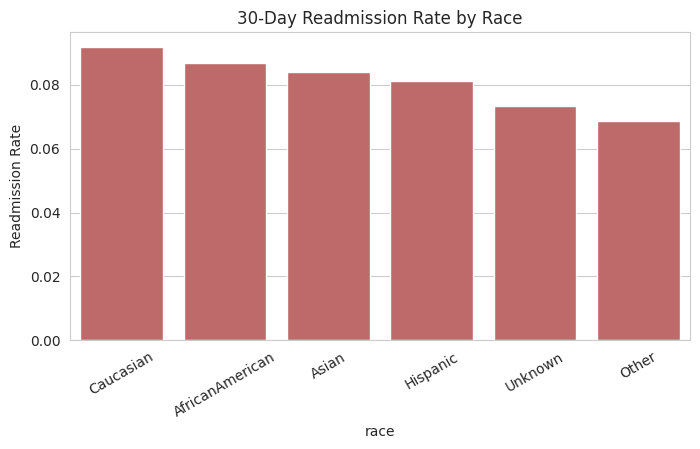

In [13]:
# readmission by race
race_readmit = df.groupby('race')['readmitted_30'].mean().sort_values(ascending=False)
print(age_readmit)

plt.figure(figsize=(8,4))
sns.barplot(x=race_readmit.index, y=race_readmit.values, color= 'indianred')
plt.title('30-Day Readmission Rate by Race')
plt.ylabel('Readmission Rate')
plt.xticks(rotation=30)
plt.show()

A1Cresult
Norm    0.086341
>7      0.086183
>8      0.081584
Name: readmitted_30, dtype: float64


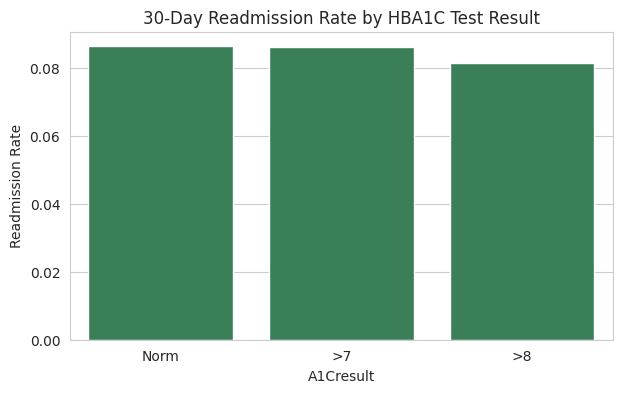

In [16]:
a1c_readmit = df.groupby('A1Cresult')['readmitted_30'].mean().sort_values(ascending=False)
print(a1c_readmit)

plt.figure(figsize=(7,4))
sns.barplot(x=a1c_readmit.index, y=a1c_readmit.values, color='seagreen')
plt.title('30-Day Readmission Rate by HBA1C Test Result')
plt.ylabel('Readmission Rate')
plt.show()

In [17]:
df.groupby('number_inpatient')['readmitted_30'].mean()

number_inpatient
0     0.081285
1     0.128838
2     0.185210
3     0.237581
4     0.236842
5     0.284314
6     0.400000
7     0.473684
8     0.230769
9     0.428571
10    0.800000
11    0.500000
12    1.000000
Name: readmitted_30, dtype: float64

In [19]:
df['A1Cresult'].value_counts(dropna=False)

A1Cresult
NaN     57144
>8       6239
Norm     3741
>7       2866
Name: count, dtype: int64

A1C_tested
False    0.091103
True     0.083995
Name: readmitted_30, dtype: float64


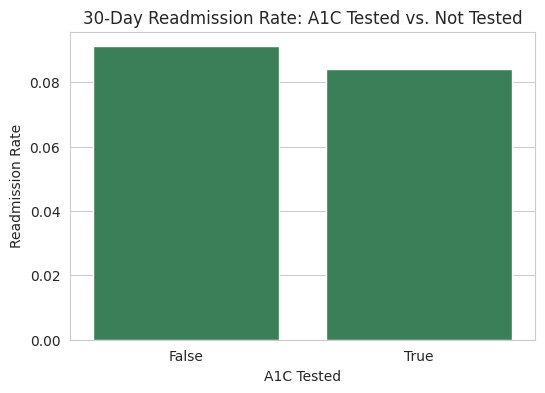

In [20]:
df['A1C_tested'] = df['A1Cresult'].notna()

tested_readmit = df.groupby('A1C_tested')['readmitted_30'].mean()
print(tested_readmit)

plt.figure(figsize=(6,4))
sns.barplot(x=tested_readmit.index, y=tested_readmit.values, color='seagreen')
plt.title('30-Day Readmission Rate: A1C Tested vs. Not Tested')
plt.ylabel('Readmission Rate')
plt.xlabel('A1C Tested')
plt.show()

number_inpatient
0     0.081285
1     0.128838
2     0.185210
3     0.237581
4     0.236842
5     0.284314
6     0.400000
7     0.473684
8     0.230769
9     0.428571
10    0.800000
11    0.500000
12    1.000000
Name: readmitted_30, dtype: float64


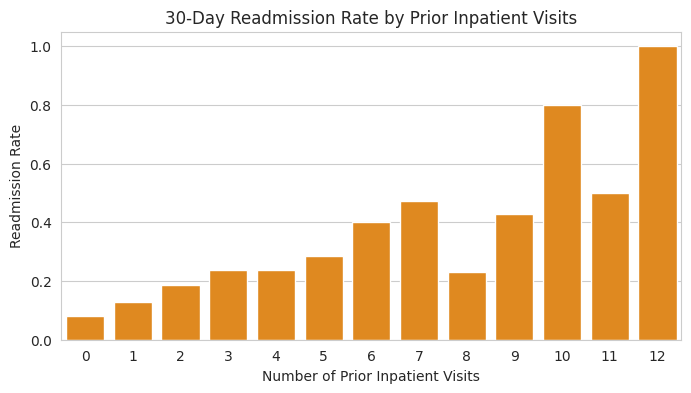

In [5]:
# readmission rate by number of prior inpatient visits
inpatient_readmit = df.groupby('number_inpatient')['readmitted_30'].mean()
print(inpatient_readmit)

plt.figure(figsize=(8,4))
sns.barplot(x=inpatient_readmit.index, y=inpatient_readmit.values, color='darkorange')
plt.title('30-Day Readmission Rate by Prior Inpatient Visits')
plt.xlabel('Number of Prior Inpatient Visits')
plt.ylabel('Readmission Rate')
plt.show()

number_emergency
0     0.087411
1     0.112542
2     0.134347
3     0.128099
4     0.242105
5     0.156250
6     0.230769
7     0.125000
8     0.222222
9     0.000000
10    0.000000
11    1.000000
13    0.000000
16    0.000000
20    0.000000
25    0.000000
37    0.000000
42    0.000000
Name: readmitted_30, dtype: float64


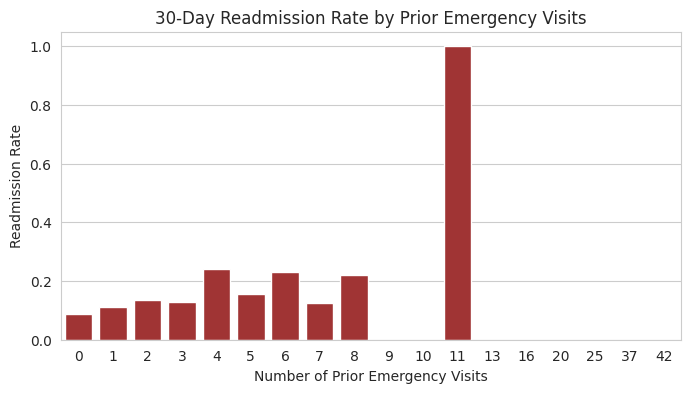

In [6]:
# readmission rate by prior emergency visits
emergency_readmit = df.groupby('number_emergency')['readmitted_30'].mean()
print(emergency_readmit)

plt.figure(figsize=(8,4))
sns.barplot(x=emergency_readmit.index, y=emergency_readmit.values, color='firebrick')
plt.title('30-Day Readmission Rate by Prior Emergency Visits')
plt.ylabel('Readmission Rate')
plt.xlabel('Number of Prior Emergency Visits')
plt.show()

number_outpatient
0    0.087994
1    0.103556
2    0.102926
3    0.086679
4    0.114983
5    0.114695
6    0.090164
7    0.097222
8    0.053571
9    0.222222
Name: readmitted_30, dtype: float64


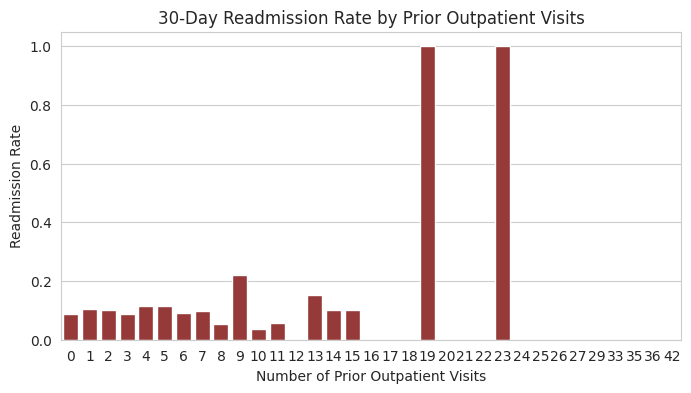

In [3]:
# finding average of prior outpatient visits
outpatient_readmit = df.groupby('number_outpatient')['readmitted_30'].mean()
print(outpatient_readmit.head(10))

plt.figure(figsize=(8,4))
sns.barplot(x=outpatient_readmit.index, y=outpatient_readmit.values, color = 'brown')
plt.title('30-Day Readmission Rate by Prior Outpatient Visits')
plt.ylabel('Readmission Rate')
plt.xlabel('Number of Prior Outpatient Visits')
plt.show()

In [5]:
# confirming whether the spikes in rate in emergency and outpatient visits are real
df['number_outpatient'].value_counts().sort_index()

number_outpatient
0     60868
1      4780
2      1982
3      1096
4       574
5       279
6       122
7        72
8        56
9        36
10       28
11       18
12       13
13       13
14       10
15       10
16        7
17        4
18        2
19        1
20        3
21        1
22        2
23        1
24        2
25        1
26        1
27        2
29        1
33        2
35        1
36        1
42        1
Name: count, dtype: int64

In [6]:
df['number_emergency'].value_counts().sort_index()

number_emergency
0     64889
1      3883
2       789
3       242
4        95
5        32
6        26
7         8
8         9
9         4
10        5
11        2
13        1
16        1
20        1
25        1
37        1
42        1
Name: count, dtype: int64

From the above output, the spikes are not true reflection of the reality on the ground.
Need to fix it by grouping into bins.

In [8]:
def bin_visits(n):
    if n == 0:
        return '0'
    elif n <= 2:
        return '1-2'
    elif n <= 5:
        return '3-5'
    else:
        return '6+'

# applying function to number_emergency and number_outpatient respectively
df['emergency_bin'] = df['number_emergency'].apply(bin_visits)
df['outpatient_bin'] = df['number_outpatient'].apply(bin_visits)

In [15]:
emergency_bin_readmit= df.groupby('emergency_bin')['readmitted_30'].mean().reindex(['0','1-2','3-5','6+'])
print(emergency_bin_readmit)

emergency_bin
0      0.087411
1-2    0.116224
3-5    0.159892
6+     0.183333
Name: readmitted_30, dtype: float64


In [16]:
outpatient_bin_readmit= df.groupby('outpatient_bin')['readmitted_30'].mean().reindex(['0','1-2','3-5','6+'])
print(outpatient_bin_readmit)

outpatient_bin
0      0.087994
1-2    0.103372
3-5    0.099025
6+     0.090024
Name: readmitted_30, dtype: float64


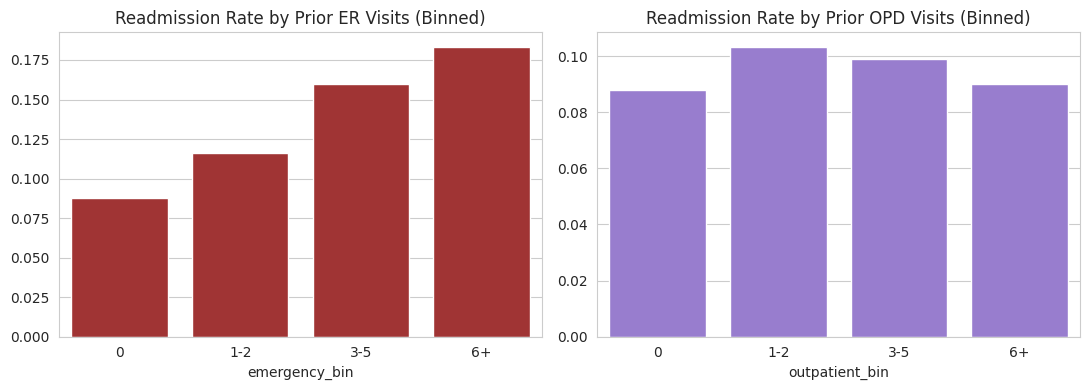

In [19]:
fig, axes = plt.subplots(1,2, figsize=(11,4))

sns.barplot(x=emergency_bin_readmit.index, y=emergency_bin_readmit.values, color='firebrick', ax=axes[0])
axes[0].set_title('Readmission Rate by Prior ER Visits (Binned)')

sns.barplot(x=outpatient_bin_readmit.index, y=outpatient_bin_readmit.values, color='mediumpurple', ax=axes[1])
axes[1].set_title('Readmission Rate by Prior OPD Visits (Binned)')

plt.tight_layout()
plt.show()


In [24]:
df[['diag_1_group','diag_2_group','diag_3_group']].head(10)

,diag_1_group,diag_2_group,diag_3_group
0,Circulatory,Circulatory,Other
1,Circulatory,Neoplasms,Respiratory
2,Neoplasms,Neoplasms,Diabetes
3,Diabetes,Circulatory,Injury
4,Circulatory,Circulatory,Diabetes
5,Neoplasms,Other,Neoplasms
6,Circulatory,Diabetes,Diabetes
7,Circulatory,Circulatory,Circulatory
8,Circulatory,Circulatory,Other
9,Respiratory,Injury,Genitourinary


diag_1_group
Missing            0.200000
Injury             0.107964
Circulatory        0.096774
Diabetes           0.091162
Neoplasms          0.090623
Other              0.089822
Genitourinary      0.089799
Musculoskeletal    0.083907
Digestive          0.080148
Respiratory        0.073017
Name: readmitted_30, dtype: float64


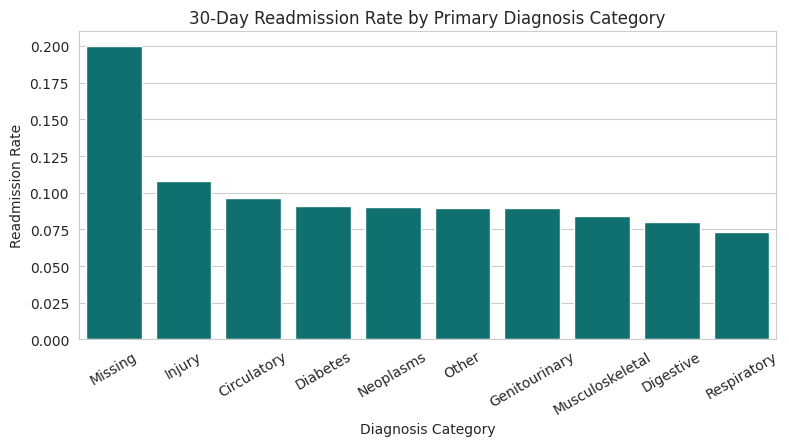

In [27]:
diag_readmit = df.groupby('diag_1_group')['readmitted_30'].mean().sort_values(ascending=False)
print(diag_readmit)

plt.figure(figsize=(9,4))
sns.barplot(x=diag_readmit.index, y=diag_readmit.values, color='teal')
plt.title('30-Day Readmission Rate by Primary Diagnosis Category')
plt.ylabel('Readmission Rate')
plt.xlabel('Diagnosis Category')
plt.xticks(rotation=30)
plt.show()

In [28]:
# confirming spikes with diag_1_group
df['diag_1_group'].value_counts()

diag_1_group
Circulatory        21390
Other              12124
Respiratory         9491
Digestive           6488
Diabetes            5748
Injury              4696
Musculoskeletal     4064
Genitourinary       3441
Neoplasms           2538
Missing               10
Name: count, dtype: int64

**The graph (30-Day Readmission Rate by Primary Diagnosis Category) is not reliable because of the 'Missing' having a frequency of 10 yet shows the highest rate. This will be fixed by converting 'Missing' to 'Other'.**

diag_1_group_cleaned
Injury             0.107964
Circulatory        0.096774
Diabetes           0.091162
Neoplasms          0.090623
Other              0.089913
Genitourinary      0.089799
Musculoskeletal    0.083907
Digestive          0.080148
Respiratory        0.073017
Name: readmitted_30, dtype: float64


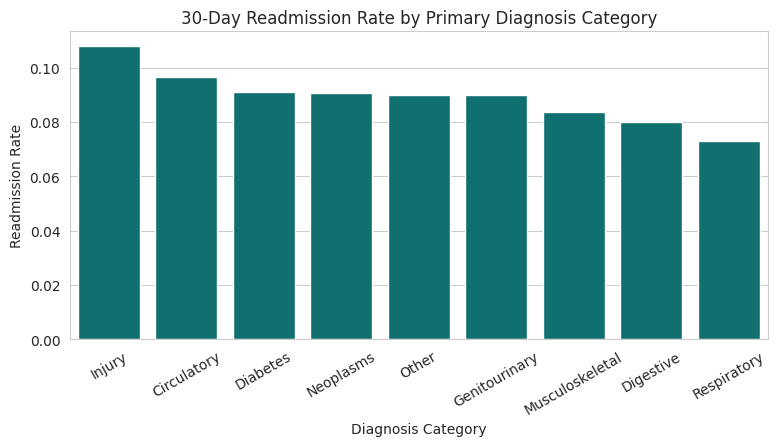

In [32]:
df['diag_1_group_cleaned'] = df['diag_1_group'].replace('Missing', 'Other')

diag_readmit = df.groupby('diag_1_group_cleaned')['readmitted_30'].mean().sort_values(ascending=False)
print(diag_readmit)

plt.figure(figsize=(9,4))
sns.barplot(x=diag_readmit.index, y=diag_readmit.values, color='teal')
plt.title('30-Day Readmission Rate by Primary Diagnosis Category')
plt.ylabel('Readmission Rate')
plt.xlabel('Diagnosis Category')
plt.xticks(rotation=30)
plt.show()

change
Ch    0.094390
No    0.086042
Name: readmitted_30, dtype: float64


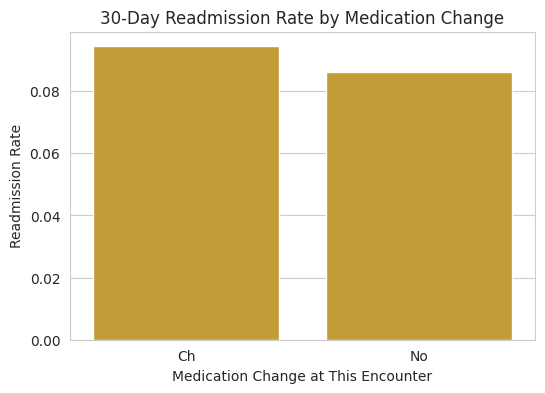

In [34]:
# medication change vs readmission
change_readmit = df.groupby('change')['readmitted_30'].mean()
print(change_readmit)

plt.figure(figsize=(6,4))
sns.barplot(x=change_readmit.index, y=change_readmit.values, color='goldenrod')
plt.title('30-Day Readmission Rate by Medication Change')
plt.ylabel('Readmission Rate')
plt.xlabel('Medication Change at This Encounter')
plt.show()

insulin
Down      0.105407
Up        0.098421
Steady    0.092641
No        0.082964
Name: readmitted_30, dtype: float64


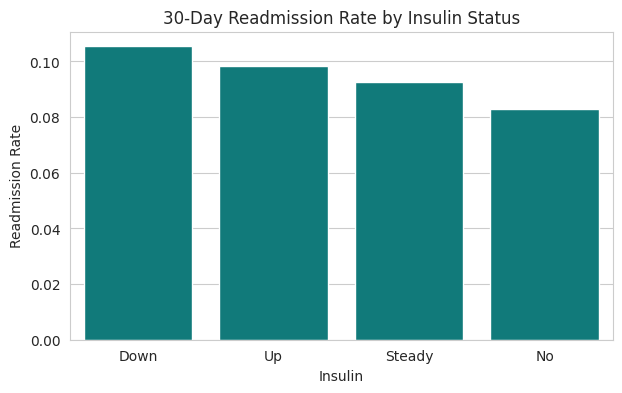

In [35]:
insulin_readmit = df.groupby('insulin')['readmitted_30'].mean().sort_values(ascending=False)
print(insulin_readmit)

plt.figure(figsize=(7,4))
sns.barplot(x=insulin_readmit.index, y=insulin_readmit.values, color='darkcyan')
plt.title('30-Day Readmission Rate by Insulin Status')
plt.ylabel('Readmission Rate')
plt.xlabel('Insulin')
plt.show()

In [36]:
df['insulin'].value_counts()

insulin
No        34268
Steady    21621
Down       7324
Up         6777
Name: count, dtype: int64

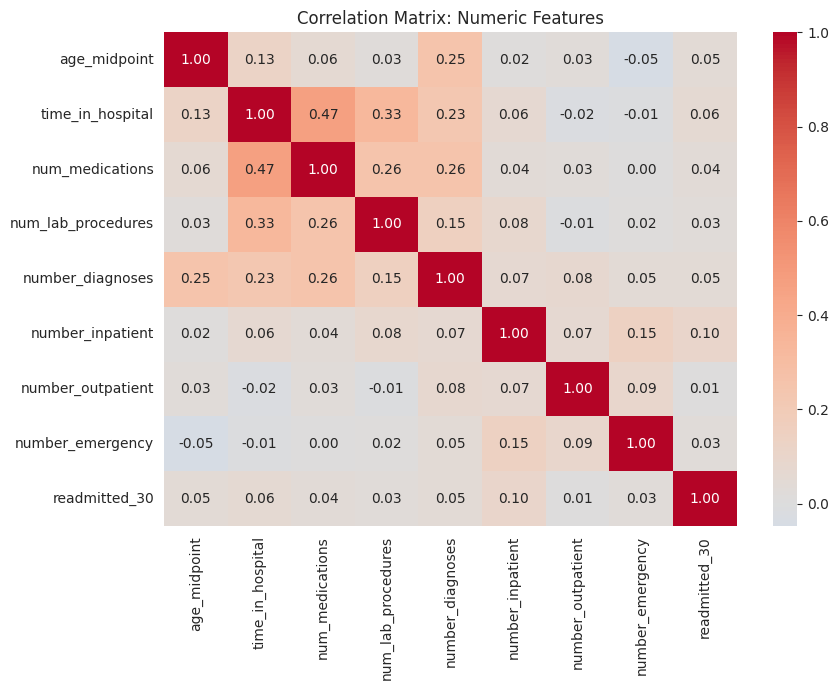

In [37]:
# correlation heatmap
numeric_cols = ['age_midpoint','time_in_hospital','num_medications','num_lab_procedures','number_diagnoses',
               'number_inpatient','number_outpatient','number_emergency','readmitted_30']
corr = df[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f',cmap='coolwarm',center=0)
plt.title('Correlation Matrix: Numeric Features')
plt.tight_layout()
plt.show()